# Wild Metadata And CLIP Analysis

Notebook liczy tylko analizę gotowych danych: JS dla oczekiwanych relacji A->B, pełne directed JS do appendixa, rozkłady metadata oraz analogiczną analizę CLIP, jeśli plik CLIP istnieje.

In [1]:
from pathlib import Path
import sys

import pandas as pd


def _find_repo_root(start: Path = Path.cwd()) -> Path:
    candidates = [start, *start.parents, start / "cgsid"]
    for candidate in candidates:
        if (candidate / "src" / "cgsid").exists():
            return candidate
    raise FileNotFoundError("Could not find the cgsid repository root")


ROOT = _find_repo_root()
sys.path.insert(0, str(ROOT / "src"))

from cgsid.analysis.tools import (
    RelationSpec,
    all_directed_js,
    build_clip_metadata_from_mappings,
    clip_accuracy_by_label,
    expected_relation_table,
    format_clip_accuracy_table,
    plot_value_distributions,
    print_relation_tabs,
    value_distribution_table,
)
from cgsid.core.config import Settings

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)


In [2]:
DATASET = "wild"
DATASET_DIR = Settings().dataset_dir(DATASET)
METADATA_PATH = DATASET_DIR / "metadata.csv"
CLIP_PATH = DATASET_DIR / "clip_scores.csv"
COLUMNS = ["object_1", "object_1_color", "object_2_color", "day_time", "season"]
EXPECTED_RELATIONS: list[RelationSpec] = [
    ("predator -> season", "object_1", "season"),
    ("time -> predator color", "day_time", "object_1_color"),
]


## Metadata

In [3]:
metadata_path = METADATA_PATH
if not metadata_path.exists():
    raise FileNotFoundError(f'Metadata file not found: {metadata_path}')
metadata = pd.read_csv(metadata_path).copy()
print(f'metadata: {metadata_path} rows={len(metadata)}')
metadata[COLUMNS].head()


metadata: /mnt/evafs/groups/mi2lab/ljaremek/cgsid_tmp/wild_correlated/metadata.csv rows=100


,object_1,object_1_color,object_2_color,day_time,season
0,fox,ginger,ginger,day,summer
1,fox,ginger,ginger,day,summer
2,fox,ginger,ginger,day,summer
3,fox,ginger,ginger,day,summer
4,fox,ginger,ginger,day,summer


## Metadata Distributions

,dataset,column,column_label,value,value_label,count,proportion
0,metadata,object_1,Animal,fox,fox,100,1.00
1,metadata,object_1_color,Color,white,white,4,0.04
2,metadata,object_1_color,Color,ginger,ginger,96,0.96
3,metadata,object_2_color,Second object color,white,white,24,0.24
4,metadata,object_2_color,Second object color,black,black,24,0.24
5,metadata,object_2_color,Second object color,brown,brown,24,0.24
6,metadata,object_2_color,Second object color,ginger,ginger,28,0.28
7,metadata,day_time,Time of day,evening,evening,20,0.20
8,metadata,day_time,Time of day,day,day,80,0.80
9,metadata,season,Season,winter,winter,16,0.16


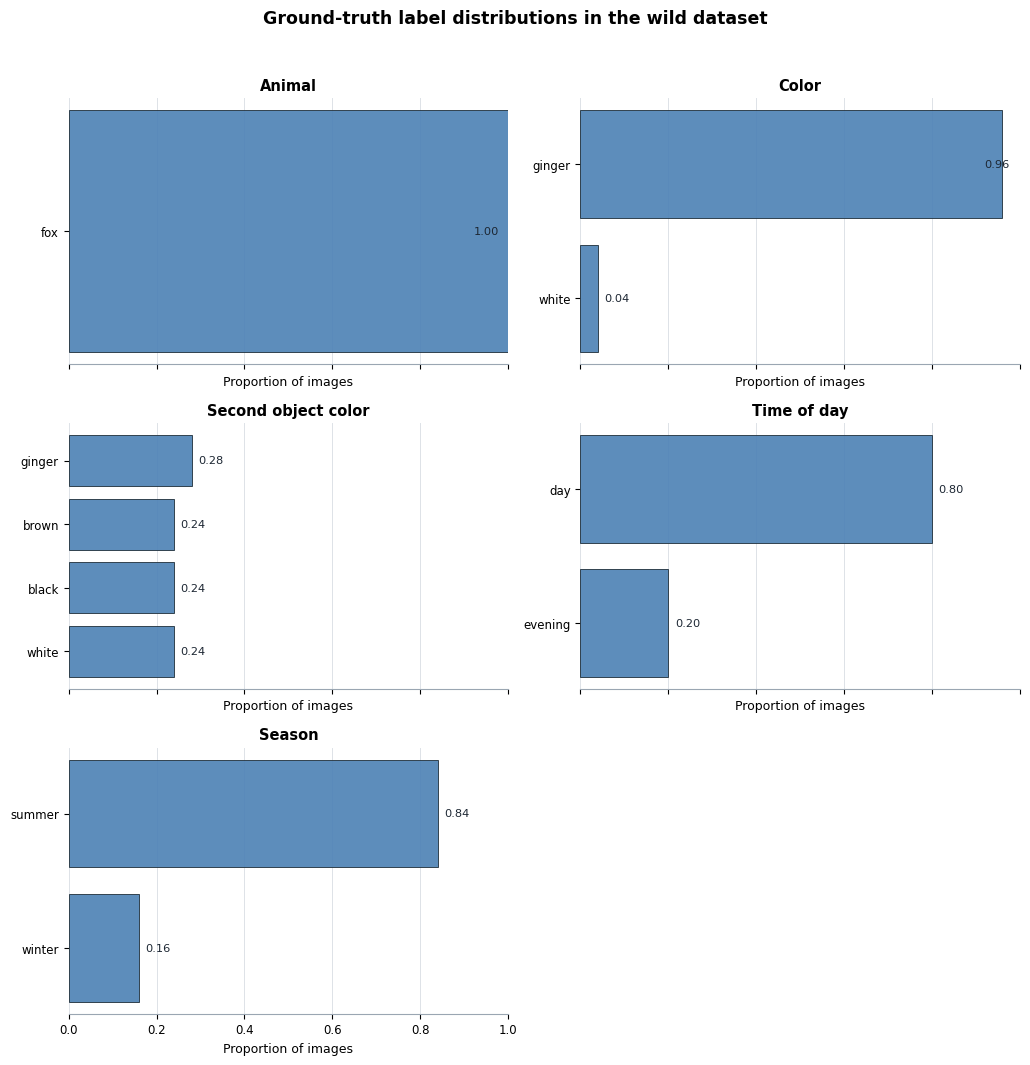

In [4]:
metadata_value_distributions = value_distribution_table(metadata[COLUMNS], "metadata")
display(metadata_value_distributions)

plot_value_distributions(
    metadata[COLUMNS],
    f"Ground-truth label distributions in the {DATASET} dataset",
    color="#4f83b6",
)


## Metadata Expected JS

In [5]:
metadata_expected_js = expected_relation_table(metadata, EXPECTED_RELATIONS)
display(metadata_expected_js)
print_relation_tabs(metadata, EXPECTED_RELATIONS)

,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value,reverse_weighted_js
0,time -> predator color,day_time,object_1_color,0.004395,0.020294,evening,0.004395
1,predator -> season,object_1,season,0.000000,0.000000,fox,0.000000



=== predator -> season: object_1 -> season ===


season,summer,winter
object_1,,
fox,0.84,0.16



=== time -> predator color: day_time -> object_1_color ===


object_1_color,ginger,white
day_time,,
day,0.95,0.05
evening,1.00,0.00


## Metadata Full JS For Appendix

In [6]:
metadata_full_js = all_directed_js(metadata, COLUMNS)
display(metadata_full_js)


,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value
0,object_2_color -> object_1_color,object_2_color,object_1_color,0.021399,0.024238,ginger
1,object_1_color -> object_2_color,object_1_color,object_2_color,0.021399,0.514958,white
2,day_time -> object_1_color,day_time,object_1_color,0.004395,0.020294,evening
3,object_1_color -> day_time,object_1_color,day_time,0.004395,0.108032,white
4,object_1_color -> season,object_1_color,season,0.003457,0.085024,white
5,season -> object_1_color,season,object_1_color,0.003457,0.020294,winter
6,season -> day_time,season,day_time,0.000502,0.002590,winter
7,day_time -> season,day_time,season,0.000502,0.001958,evening
8,object_2_color -> day_time,object_2_color,day_time,0.000207,0.000540,ginger
9,day_time -> object_2_color,day_time,object_2_color,0.000207,0.000834,evening


## CLIP

In [7]:
CLIP_MAPPINGS: dict[str, dict[str, str]] = {
    "object_1": {
        "fox": "wild_predator_fox",
        "dog": "wild_predator_dog",
        "cat": "wild_predator_cat",
    },
    "object_2": {
        "hare": "wild_prey_hare",
        "mouse": "wild_prey_mouse",
    },
    "object_1_color": {
        "ginger": "wild_predator_color_ginger",
        "white": "wild_predator_color_white",
        "black": "wild_predator_color_black",
        "brown": "wild_predator_color_brown",
    },
    "object_2_color": {
        "ginger": "wild_prey_color_ginger",
        "white": "wild_prey_color_white",
        "black": "wild_prey_color_black",
        "brown": "wild_prey_color_brown",
    },
    "day_time": {
        "day": "wild_time_day",
        "evening": "wild_time_evening",
    },
    "season": {
        "summer": "season_summer",
        "winter": "season_winter",
    },
}


def build_clip_metadata(clip: pd.DataFrame) -> pd.DataFrame:
    return build_clip_metadata_from_mappings(clip, CLIP_MAPPINGS)


In [8]:
clip_path = CLIP_PATH
if not clip_path.exists():
    clip = None
    print(f'clip: no file found at {clip_path}')
    print('No CLIP results found yet. Run 2_query_dataset_with_clip_wild.py, then rerun from this cell.')
else:
    clip = pd.read_csv(clip_path)
    print(f'clip: {clip_path} rows={len(clip)}')
    clip_pred = build_clip_metadata(clip)
    display(clip_pred[COLUMNS].head())


clip: /mnt/evafs/groups/mi2lab/ljaremek/cgsid_tmp/wild_correlated/clip_scores.csv rows=100


,object_1,object_1_color,object_2_color,day_time,season
0,fox,ginger,ginger,day,summer
1,fox,white,brown,day,summer
2,fox,ginger,ginger,day,summer
3,fox,white,brown,day,summer
4,fox,white,ginger,evening,summer


## CLIP Distributions

,dataset,column,column_label,value,value_label,count,proportion
0,clip,object_1,Animal,fox,fox,100,1.00
1,clip,object_1_color,Color,brown,brown,2,0.02
2,clip,object_1_color,Color,ginger,ginger,9,0.09
3,clip,object_1_color,Color,black,black,18,0.18
4,clip,object_1_color,Color,white,white,71,0.71
5,clip,object_2_color,Second object color,white,white,6,0.06
6,clip,object_2_color,Second object color,brown,brown,28,0.28
7,clip,object_2_color,Second object color,ginger,ginger,66,0.66
8,clip,day_time,Time of day,evening,evening,45,0.45
9,clip,day_time,Time of day,day,day,55,0.55


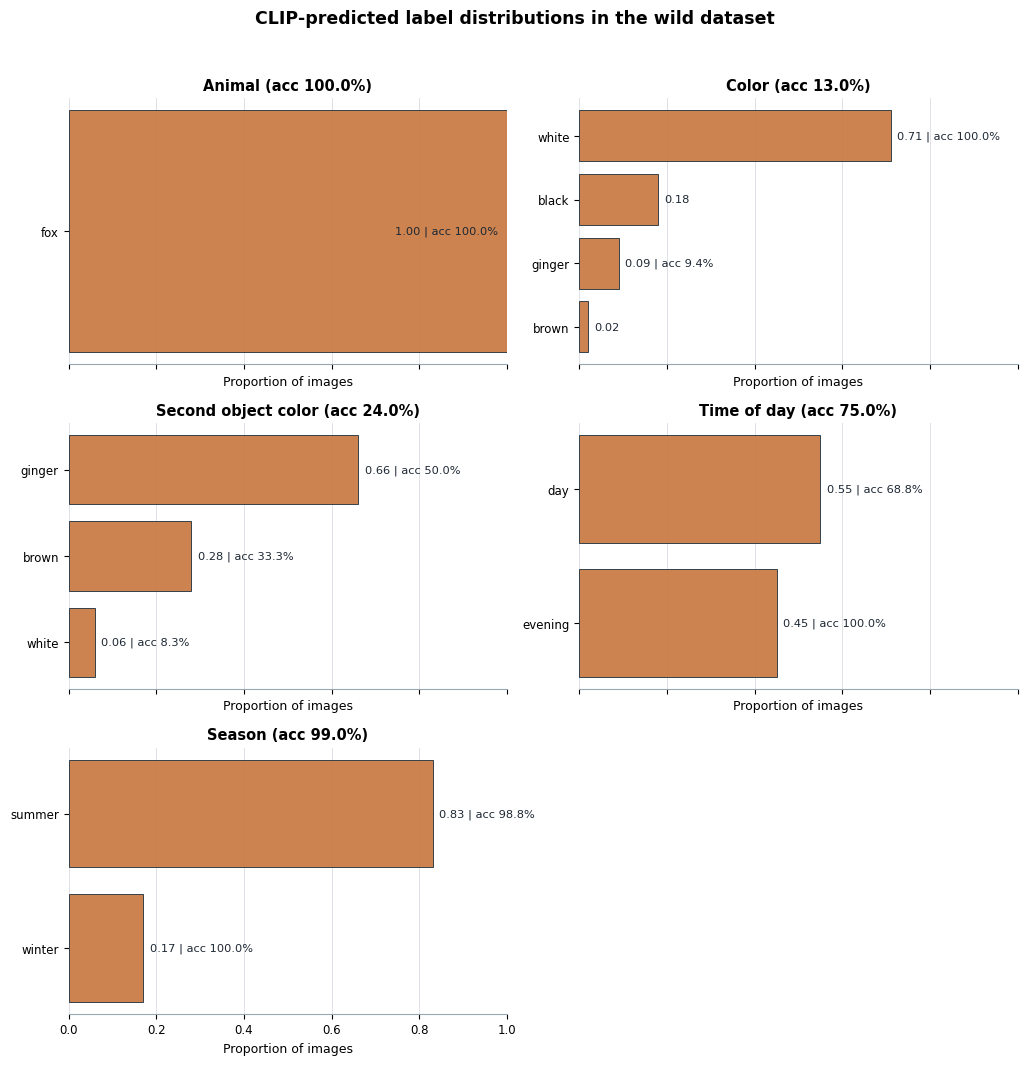

In [9]:
if clip is not None:
    clip_value_distributions = value_distribution_table(clip_pred[COLUMNS], "clip")
    display(clip_value_distributions)
    clip_accuracy_suffixes = {
        column: f"acc {100 * metadata[column].reset_index(drop=True).eq(clip_pred[column].reset_index(drop=True)).mean():.1f}%"
        for column in COLUMNS
    }
    clip_label_accuracy_suffixes = {}
    for column in COLUMNS:
        truth = metadata[column].reset_index(drop=True)
        pred = clip_pred[column].reset_index(drop=True)
        correct = truth.eq(pred)
        for value in sorted(truth.dropna().unique(), key=str):
            mask = truth.eq(value)
            if mask.any():
                clip_label_accuracy_suffixes[(column, value)] = f"acc {100 * correct[mask].mean():.1f}%"

    plot_value_distributions(
        clip_pred[COLUMNS],
        f"CLIP-predicted label distributions in the {DATASET} dataset",
        color="#c87941",
        title_suffixes=clip_accuracy_suffixes,
        value_suffixes=clip_label_accuracy_suffixes,
    )


## CLIP Expected JS

In [10]:
if clip is not None:
    clip_expected_js = expected_relation_table(clip_pred, EXPECTED_RELATIONS)
    display(clip_expected_js)
    print_relation_tabs(clip_pred, EXPECTED_RELATIONS)

,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value,reverse_weighted_js
0,time -> predator color,day_time,object_1_color,0.012069,0.014529,day,0.012069
1,predator -> season,object_1,season,0.000000,0.000000,fox,0.000000



=== predator -> season: object_1 -> season ===


season,summer,winter
object_1,,
fox,0.83,0.17



=== time -> predator color: day_time -> object_1_color ===


object_1_color,black,brown,ginger,white
day_time,,,,
day,0.127,0.000,0.091,0.782
evening,0.244,0.044,0.089,0.622


## CLIP Full JS For Appendix

In [11]:
if clip is not None:
    clip_full_js = all_directed_js(clip_pred, COLUMNS)
    display(clip_full_js)


,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value
0,object_2_color -> object_1_color,object_2_color,object_1_color,0.028388,0.162824,white
1,object_1_color -> object_2_color,object_1_color,object_2_color,0.028388,0.195295,ginger
2,object_1_color -> day_time,object_1_color,day_time,0.012069,0.352161,brown
3,day_time -> object_1_color,day_time,object_1_color,0.012069,0.014529,day
4,object_1_color -> season,object_1_color,season,0.010612,0.090704,brown
5,season -> object_1_color,season,object_1_color,0.010612,0.058047,winter
6,day_time -> object_2_color,day_time,object_2_color,0.005731,0.008243,evening
7,object_2_color -> day_time,object_2_color,day_time,0.005731,0.069842,white
8,season -> day_time,season,day_time,0.003820,0.018862,winter
9,day_time -> season,day_time,season,0.003820,0.005210,evening


## Metadata vs CLIP Summary

In [12]:
if clip is not None:
    comparison = metadata_expected_js.merge(clip_expected_js, on=['relation', 'condition_column', 'target_column'], suffixes=('_metadata', '_clip'))
    comparison['weighted_js_delta_metadata_minus_clip'] = comparison['weighted_js_metadata'] - comparison['weighted_js_clip']
    display(comparison)

    wjs_comparison = metadata_full_js.merge(clip_full_js, on=['relation', 'condition_column', 'target_column'], suffixes=('_metadata', '_clip'))
    wjs_summary = wjs_comparison[['relation', 'weighted_js_metadata', 'weighted_js_clip']].rename(columns={
        'weighted_js_metadata': 'wjs (raw)',
        'weighted_js_clip': 'wjs (clip)',
    })
    wjs_summary = (
        wjs_summary
        .assign(_raw_sort=wjs_summary['wjs (raw)'].round(6), _clip_sort=wjs_summary['wjs (clip)'].round(6))
        .sort_values(['_raw_sort', '_clip_sort'], ascending=False)
        .drop(columns=['_raw_sort', '_clip_sort'])
        .reset_index(drop=True)
    )
    display(wjs_summary.style.format({'wjs (raw)': '{:.6f}', 'wjs (clip)': '{:.6f}'}))

,relation,condition_column,target_column,weighted_js_metadata,max_js_metadata,strongest_condition_value_metadata,reverse_weighted_js_metadata,weighted_js_clip,max_js_clip,strongest_condition_value_clip,reverse_weighted_js_clip,weighted_js_delta_metadata_minus_clip
0,time -> predator color,day_time,object_1_color,0.004395,0.020294,evening,0.004395,0.012069,0.014529,day,0.012069,-0.007673
1,predator -> season,object_1,season,0.000000,0.000000,fox,0.000000,0.000000,0.000000,fox,0.000000,0.000000


,relation,wjs (raw),wjs (clip)
0,object_2_color -> object_1_color,0.021399,0.028388
1,object_1_color -> object_2_color,0.021399,0.028388
2,day_time -> object_1_color,0.004395,0.012069
3,object_1_color -> day_time,0.004395,0.012069
4,object_1_color -> season,0.003457,0.010612
5,season -> object_1_color,0.003457,0.010612
6,season -> day_time,0.000502,0.003820
7,day_time -> season,0.000502,0.003820
8,object_2_color -> day_time,0.000207,0.005731
9,day_time -> object_2_color,0.000207,0.005731
